# 3 - New Pipeline

In [1]:
#Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
import hail_model_spatialfragility as hs

In [3]:
# This information helps with debugging and getting support :)
import sys, platform
print("Working on a ", platform.system(), platform.release())
print("Python version ", sys.version)
print("Pandas version ", pd.__version__)
#print("PV_ICE version ", PV_ICE.__version__)

Working on a  Windows 11
Python version  3.13.5 | packaged by Anaconda, Inc. | (main, Jun 12 2025, 16:37:03) [MSC v.1929 64 bit (AMD64)]
Pandas version  2.2.3


In [4]:
# ## Input data

# Location-specific hail return periods
hail_return = pd.read_csv("Hail_return_period.csv")

# Location-specific Gamma hail-size distributions
hail_dist = pd.read_csv("Hail_size_distribution_discrete_locations.csv")

# Post-hail degradation distribution
plr_cdf = pd.read_csv("plr_increase_after_1in_hail.csv")
plr_cdf.columns = plr_cdf.columns.str.strip()

# Module-area-dependent fragility curves
fragility_curves = pd.read_csv("fragility_curves.csv")

In [5]:
# Hail-footprint area distributions conditional on hail-size bin

# Hail-footprint area CDFs conditional on hail-size bin
footprint_cdfs = {
    "0_1": pd.read_csv("hail_area_0_1.csv"),
    "1_2": pd.read_csv("hail_area_1_2.csv"),
    "2_3": pd.read_csv("hail_area_2_3.csv"),
    "3_4": pd.read_csv("hail_area_3_4.csv"),
}

In [6]:
# ## Spatial inputs

# County areas used to convert sampled hail-footprint area
# into the probability that the modeled site lies within the footprint.

county_areas = pd.DataFrame({
    "Location": ["Austin", "Phoenix", "Denver"],
    "County": ["Travis County", "Maricopa County", "Denver County"],
    "A_total_sqmi": [1025.027, 9225.996, 154.725]
})

county_areas

,Location,County,A_total_sqmi
0,Austin,Travis County,1025.027
1,Phoenix,Maricopa County,9225.996
2,Denver,Denver County,154.725


In [7]:
# ## Baseline simulation assumptions

P0_MW = 100
years = np.arange(0, 51)

location = "Austin"

T50 = 39
T90 = 42

module_area_m2 = 2.0

N_SIMS = 200
BASE_SEED = 100

In [8]:
# ## Input sanity checks

A, B, C, D, E = hs.get_fragility_params(
    module_area_m2, fragility_curves
)

print("Module area:", module_area_m2, "m²")
print("Fragility parameters:")
print("A =", A)
print("B =", B)
print("C =", C)
print("D =", D)
print("E =", E)

Module area: 2.0 m²
Fragility parameters:
A = 0.0
B = 2.229592
C = 5.411271
D = 105.0
E = 5.0


In [9]:
for hail_size in [1.0, 2.0, 3.0]:
    damage = hs.damage_fraction_from_fragility(
        hail_size, module_area_m2, fragility_curves
    )

    print(
        f"{hail_size:.1f} in hail -> "
        f"{100 * damage:.1f}% visible system damage"
    )

1.0 in hail -> 11.4% visible system damage
2.0 in hail -> 42.3% visible system damage
3.0 in hail -> 73.0% visible system damage


### Single-project simulation

For each simulated year:

 1. Apply intrinsic Weibull reliability failures.
 2. Determine whether a county-level hail event occurs.
 3. If so, sample hail diameter from the location-specific Gamma distribution.
 4. Sample hail-footprint area conditional on hail diameter.
 5. Convert footprint area to spatial coverage and determine whether the site is hit.
 6. If hit, calculate visible system damage using the module-area-dependent fragility curve.
 7. Optionally apply additional degradation to hail-damaged survivors.

In [10]:
# ## Baseline simulation assumptions

P0_MW = 100
years = np.arange(0, 51)

location = "Austin"

T50 = 39
T90 = 42

module_area_m2 = 2.0

N_SIMS = 200
BASE_SEED = 100

res_city = hs.simulate_project_spatial(
    P0_MW=P0_MW,
    location=location,
    years=years,
    hail_return=hail_return,
    hail_dist=hail_dist,
    footprint_cdfs=footprint_cdfs,
    county_areas=county_areas,
    fragility_curves=fragility_curves,
    module_area_m2=module_area_m2,
    plr_cdf=plr_cdf,
    t50=T50,
    t90=T90,
    seed=42,
    use_post_hail_plr=True,
    track_hail_buckets=True,
    apply_plr_once=True,
    debug=True
)

Year: 5 | county event: True | hail size: 0.6825501673960299 | footprint: 982.1745428945889 | coverage: 0.9581938260110112 | site hit: True | fragility damage: 0.05042056896208649 | sampled PLR: 0.0073770384133430445
Year: 24 | county event: True | hail size: 0.8688392045222559 | footprint: 749.8405668707231 | coverage: 0.7315325029201407 | site hit: True | fragility damage: 0.08458590801099561 | sampled PLR: 0.018155792509756703


In [11]:
# Inspect years in which a county hail event occurred

res_city.loc[
    res_city["county_hail_event"],
    [
        "year",
        "county_hail_event",
        "hail_size_in",
        "footprint_area_sqmi",
        "coverage_fraction",
        "site_hit",
        "f_cat",
        "hail_failures_MW",
        "plr_added_this_year",
        "available_capacity_MW_end",
        "effective_capacity_MW_end"
    ]
]

,year,county_hail_event,hail_size_in,footprint_area_sqmi,coverage_fraction,site_hit,f_cat,hail_failures_MW,plr_added_this_year,available_capacity_MW_end,effective_capacity_MW_end
5,5,True,0.682550,982.174543,0.958194,True,0.050421,5.042057,0.007377,94.957943,94.957943
13,13,True,1.854306,41.775980,0.040756,False,0.000000,0.000000,0.000000,94.957942,89.496454
19,19,True,1.537645,40.750935,0.039756,False,0.000000,0.000000,0.000000,94.957369,85.606968
24,24,True,0.868839,749.840567,0.731533,True,0.084586,8.029967,0.000000,86.902713,75.497985
32,32,True,1.713788,43.994183,0.042920,False,0.000000,0.000000,0.000000,84.515546,69.201127
37,37,True,2.336551,170.421618,0.166261,False,0.000000,0.000000,0.000000,64.691503,51.044082
43,43,True,1.044207,21.926432,0.021391,False,0.000000,0.000000,0.000000,2.986201,2.253840
45,45,True,1.592138,34.595826,0.033751,False,0.000000,0.000000,0.000000,0.076102,0.056593


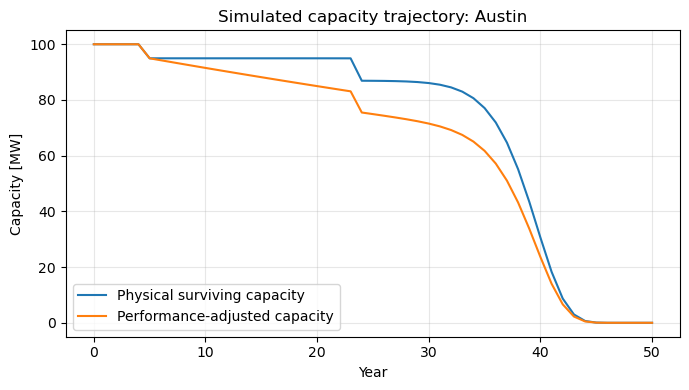

In [12]:
# ## Capacity trajectory

plt.figure(figsize=(7, 4))

plt.plot(
    res_city["year"],
    res_city["available_capacity_MW_end"],
    label="Physical surviving capacity"
)

plt.plot(
    res_city["year"],
    res_city["effective_capacity_MW_end"],
    label="Performance-adjusted capacity"
)

plt.xlabel("Year")
plt.ylabel("Capacity [MW]")
plt.title(f"Simulated capacity trajectory: {location}")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## TIME CHECK - Batch 1k

In [13]:
import time

t0 = time.time()

mc_test = hs.run_monte_carlo_spatial(
    n_sims=1000,
    P0_MW=P0_MW,
    location="Austin",
    years=years,
    hail_return=hail_return,
    hail_dist=hail_dist,
    footprint_cdfs=footprint_cdfs,
    county_areas=county_areas,
    fragility_curves=fragility_curves,
    module_area_m2=module_area_m2,
    plr_cdf=plr_cdf,
    t50=T50,
    t90=T90,
    base_seed=BASE_SEED,
)

elapsed = time.time() - t0
print(f"1000 runs: {elapsed:.1f} s")
print(f"Estimated 10000 runs: {elapsed * 10 / 60:.1f} min")

1000 runs: 18.8 s
Estimated 10000 runs: 3.1 min


## Fig 5 Monte Carlo for Austin

In [14]:
# ## Monte Carlo simulation: Austin

location = "Austin"
N_SIMS = 10000

mc_austin = hs.run_monte_carlo_spatial(
    n_sims=N_SIMS,
    P0_MW=P0_MW,
    location=location,
    years=years,
    hail_return=hail_return,
    hail_dist=hail_dist,
    footprint_cdfs=footprint_cdfs,
    county_areas=county_areas,
    fragility_curves=fragility_curves,
    module_area_m2=module_area_m2,
    plr_cdf=plr_cdf,
    t50=T50,
    t90=T90,
    base_seed=BASE_SEED,
    use_post_hail_plr=True,
    track_hail_buckets=True,
    apply_plr_once=True,
)

In [15]:
mc_austin.head()

,year,county_hail_event,site_hit,hail_size_in,footprint_area_sqmi,coverage_fraction,hail_event,f_rel,f_cat,plr_added_this_year,...,undamaged_MW_end,hail_damaged_MW_end,available_capacity_MW_end,effective_capacity_MW_end,reliability_failures_MW,hail_failures_MW,total_failures_MW,S_total,available_capacity_MW_start,sim
0,0,False,False,0.000000,0.000000,0.000000,False,0.000000e+00,0.000000,0.000000,...,100.0,0.00000,100.00000,100.00000,0.000000e+00,0.00000,0.00000,1.000000,100.0,0
1,1,False,False,0.000000,0.000000,0.000000,False,0.000000e+00,0.000000,0.000000,...,100.0,0.00000,100.00000,100.00000,0.000000e+00,0.00000,0.00000,1.000000,100.0,0
2,2,False,False,0.000000,0.000000,0.000000,False,0.000000e+00,0.000000,0.000000,...,100.0,0.00000,100.00000,100.00000,0.000000e+00,0.00000,0.00000,1.000000,100.0,0
3,3,False,False,0.000000,0.000000,0.000000,False,0.000000e+00,0.000000,0.000000,...,100.0,0.00000,100.00000,100.00000,0.000000e+00,0.00000,0.00000,1.000000,100.0,0
4,4,True,True,0.817045,993.571446,0.969312,True,1.110223e-16,0.074223,0.012531,...,0.0,92.57775,92.57775,92.57775,1.110223e-14,7.42225,7.42225,0.925777,100.0,0


In [16]:
mc_austin["site_hit"].mean()

np.float64(0.03285294117647059)

In [17]:
summary_year = 30

through_year = mc_austin[mc_austin["year"] <= summary_year]

sims_with_hit = (
    through_year.groupby("sim")["site_hit"]
    .any()
    .mean()
)

print(f"Fraction of simulations with >=1 site hit by year {summary_year}: {sims_with_hit:.2%}")

Fraction of simulations with >=1 site hit by year 30: 63.79%


In [18]:
# ## Summarize Monte Carlo capacity outcomes

mc_summary = (
    mc_austin.groupby("year")
    .agg(
        physical_p10=("available_capacity_MW_end", lambda x: np.percentile(x, 10)),
        physical_p50=("available_capacity_MW_end", "median"),
        physical_p90=("available_capacity_MW_end", lambda x: np.percentile(x, 90)),
        effective_p10=("effective_capacity_MW_end", lambda x: np.percentile(x, 10)),
        effective_p50=("effective_capacity_MW_end", "median"),
        effective_p90=("effective_capacity_MW_end", lambda x: np.percentile(x, 90)),
    )
    .reset_index()
)

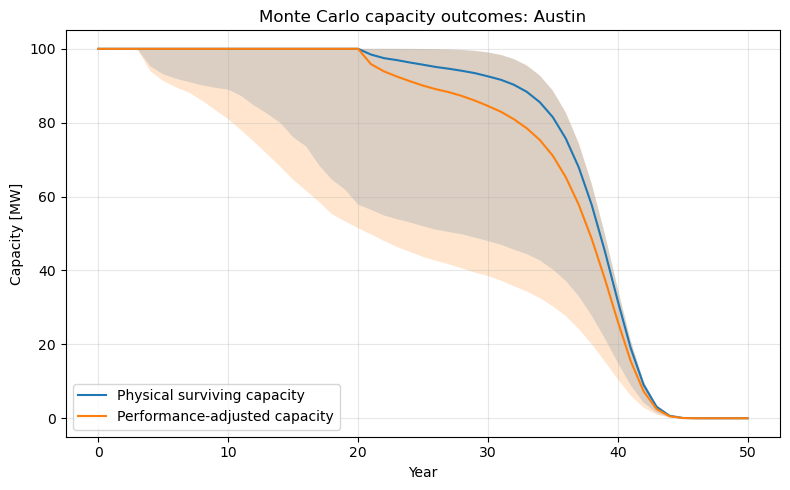

In [19]:
# ## Monte Carlo capacity trajectory

plt.figure(figsize=(8, 5))

plt.plot(
    mc_summary["year"],
    mc_summary["physical_p50"],
    label="Physical surviving capacity"
)
plt.fill_between(
    mc_summary["year"],
    mc_summary["physical_p10"],
    mc_summary["physical_p90"],
    alpha=0.2
)

plt.plot(
    mc_summary["year"],
    mc_summary["effective_p50"],
    label="Performance-adjusted capacity"
)
plt.fill_between(
    mc_summary["year"],
    mc_summary["effective_p10"],
    mc_summary["effective_p90"],
    alpha=0.2
)

plt.xlabel("Year")
plt.ylabel("Capacity [MW]")
plt.title(f"Monte Carlo capacity outcomes: {location}")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Fig. 6 Austin Vs Phoenix 

In [20]:
# ## Monte Carlo simulation: Phoenix

mc_phoenix = hs.run_monte_carlo_spatial(
    n_sims=N_SIMS,
    P0_MW=P0_MW,
    location="Phoenix",
    years=years,
    hail_return=hail_return,
    hail_dist=hail_dist,
    footprint_cdfs=footprint_cdfs,
    county_areas=county_areas,
    fragility_curves=fragility_curves,
    module_area_m2=module_area_m2,
    plr_cdf=plr_cdf,
    t50=T50,
    t90=T90,
    base_seed=BASE_SEED,
    use_post_hail_plr=True,
    track_hail_buckets=True,
    apply_plr_once=True,
)

In [21]:
N_SIMS

10000

In [22]:
# ## Austin vs Phoenix at evaluation year

evaluation_year = 30

austin_eval = mc_austin[
    mc_austin["year"] == evaluation_year
].copy()

phoenix_eval = mc_phoenix[
    mc_phoenix["year"] == evaluation_year
].copy()

In [23]:
# ## Summary statistics

def summarize_location(df, location):
    x = df["effective_capacity_MW_end"]

    return {
        "Location": location,
        "Median capacity [MW]": np.median(x),
        "P10 capacity [MW]": np.percentile(x, 10),
        "P90 capacity [MW]": np.percentile(x, 90),
        "Median capacity [%]": 100 * np.median(x) / P0_MW,
        "P10 capacity [%]": 100 * np.percentile(x, 10) / P0_MW,
        "P90 capacity [%]": 100 * np.percentile(x, 90) / P0_MW,
    }

results_eval = pd.DataFrame([
    summarize_location(austin_eval, "Austin"),
    summarize_location(phoenix_eval, "Phoenix"),
])

results_eval

,Location,Median capacity [MW],P10 capacity [MW],P90 capacity [MW],Median capacity [%],P10 capacity [%],P90 capacity [%]
0,Austin,84.541953,38.497160,99.016432,84.541953,38.497160,99.016432
1,Phoenix,99.016432,99.016432,99.016432,99.016432,99.016432,99.016432


In [28]:
# ## Phoenix vs. Austin Monte Carlo capacity trajectories

def summarize_mc_capacity(mc):
    return (
        mc.groupby("year")["effective_capacity_MW_end"]
        .agg(
            median="median",
            p10=lambda x: np.percentile(x, 10),
            p90=lambda x: np.percentile(x, 90),
        )
        .reset_index()
    )

austin_summary = summarize_mc_capacity(mc_austin)
phoenix_summary = summarize_mc_capacity(mc_phoenix)

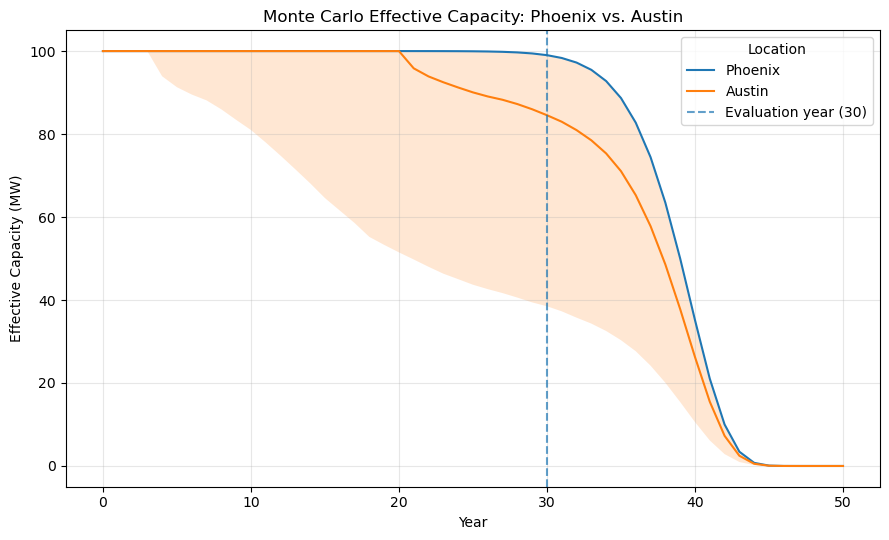

In [29]:
plt.figure(figsize=(9, 5.5))

# Phoenix
plt.plot(
    phoenix_summary["year"],
    phoenix_summary["median"],
    label="Phoenix"
)
plt.fill_between(
    phoenix_summary["year"],
    phoenix_summary["p10"],
    phoenix_summary["p90"],
    alpha=0.18
)

# Austin
plt.plot(
    austin_summary["year"],
    austin_summary["median"],
    label="Austin"
)
plt.fill_between(
    austin_summary["year"],
    austin_summary["p10"],
    austin_summary["p90"],
    alpha=0.18
)

# Evaluation year
plt.axvline(
    evaluation_year,
    linestyle="--",
    alpha=0.7,
    label=f"Evaluation year ({evaluation_year})"
)

plt.xlabel("Year")
plt.ylabel("Effective Capacity (MW)")
plt.title("Monte Carlo Effective Capacity: Phoenix vs. Austin")
plt.legend(title="Location")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

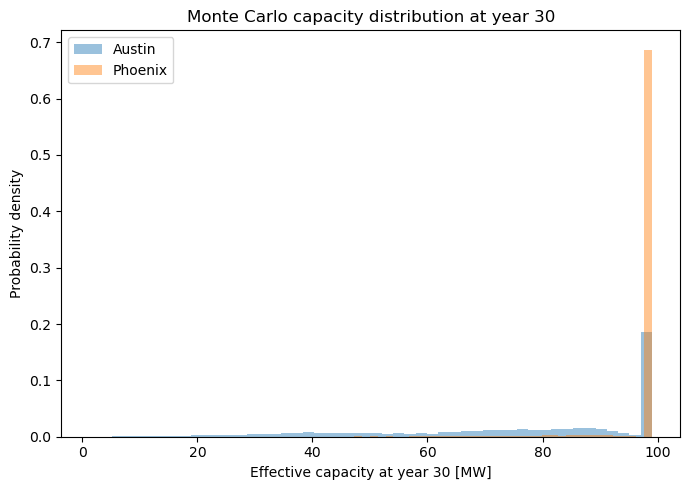

In [24]:
# ## Distribution of capacity at evaluation year

plt.figure(figsize=(7, 5))

plt.hist(
    austin_eval["effective_capacity_MW_end"],
    bins=50, density=True, alpha=0.45,
    label="Austin"
)

plt.hist(
    phoenix_eval["effective_capacity_MW_end"],
    bins=50, density=True, alpha=0.45,
    label="Phoenix"
)

plt.xlabel(f"Effective capacity at year {evaluation_year} [MW]")
plt.ylabel("Probability density")
plt.title(f"Monte Carlo capacity distribution at year {evaluation_year}")
plt.legend()
plt.tight_layout()
plt.show()

In [25]:
# ## Hail-event statistics through evaluation year

def summarize_hail(mc, location, evaluation_year):
    df = mc[mc["year"] <= evaluation_year]

    by_sim = df.groupby("sim").agg(
        any_county_hail=("county_hail_event", "any"),
        any_site_hit=("site_hit", "any"),
        n_site_hits=("site_hit", "sum"),
        total_hail_failure_MW=("hail_failures_MW", "sum"),
    )

    return {
        "Location": location,
        "P(any county hail)": by_sim["any_county_hail"].mean(),
        "P(any site hit)": by_sim["any_site_hit"].mean(),
        "Mean site hits": by_sim["n_site_hits"].mean(),
        "Median hail failures [MW]": by_sim["total_hail_failure_MW"].median(),
        "P90 hail failures [MW]": by_sim["total_hail_failure_MW"].quantile(0.90),
    }

hail_results = pd.DataFrame([
    summarize_hail(mc_austin, "Austin", evaluation_year),
    summarize_hail(mc_phoenix, "Phoenix", evaluation_year),
])

hail_results

,Location,P(any county hail),P(any site hit),Mean site hits,Median hail failures [MW],P90 hail failures [MW]
0,Austin,0.9952,0.6379,1.0007,6.524712,51.483588
1,Phoenix,0.8559,0.0645,0.0669,0.000000,0.000000


C:\Users\sayala\AppData\Local\Temp\ipykernel_25276\1154168120.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


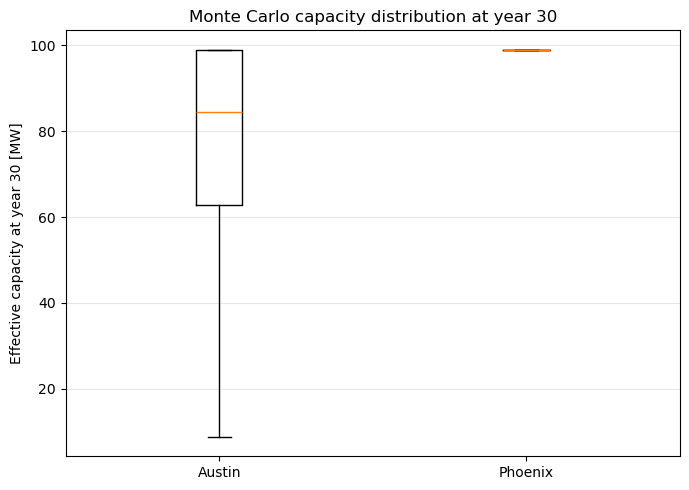

In [26]:
plt.figure(figsize=(7, 5))

plt.boxplot(
    [
        austin_eval["effective_capacity_MW_end"],
        phoenix_eval["effective_capacity_MW_end"]
    ],
    labels=["Austin", "Phoenix"],
    showfliers=False
)

plt.ylabel(f"Effective capacity at year {evaluation_year} [MW]")
plt.title(f"Monte Carlo capacity distribution at year {evaluation_year}")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

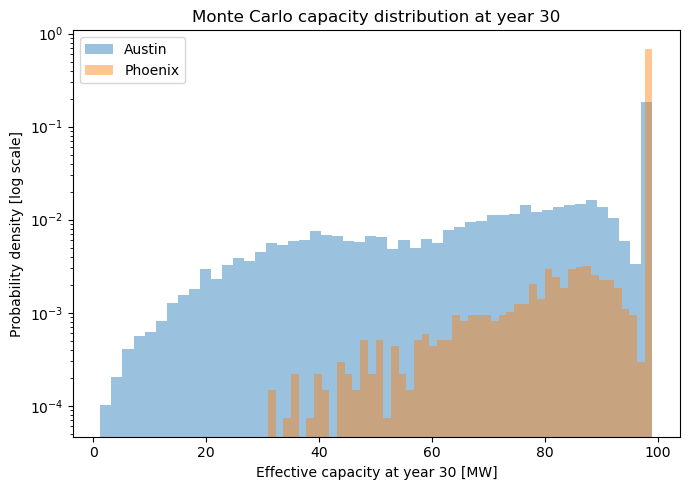

In [27]:
# ## Distribution of capacity at evaluation year — log y-axis

plt.figure(figsize=(7, 5))

plt.hist(
    austin_eval["effective_capacity_MW_end"],
    bins=50, density=True, alpha=0.45,
    label="Austin"
)

plt.hist(
    phoenix_eval["effective_capacity_MW_end"],
    bins=50, density=True, alpha=0.45,
    label="Phoenix"
)

plt.yscale("log")

plt.xlabel(f"Effective capacity at year {evaluation_year} [MW]")
plt.ylabel("Probability density [log scale]")
plt.title(f"Monte Carlo capacity distribution at year {evaluation_year}")
plt.legend()
plt.tight_layout()
plt.show()

## Fig 10 - Module Area Fragility Curve Case

In [31]:
module_area_m2 = 2.0

In [11]:
module_cases = {
    "<1.5 m²": 1.4,
    "1.5–2 m²": 1.75,
    "2+ m²": 2.1,
}

N_SIMS = 10000

mc_by_area = {}

for label, module_area in module_cases.items():
    mc_by_area[label] = hs.run_monte_carlo_spatial(
        n_sims=N_SIMS,
        P0_MW=P0_MW,
        location="Austin",
        years=years,
        hail_return=hail_return,
        hail_dist=hail_dist,
        footprint_cdfs=footprint_cdfs,
        county_areas=county_areas,
        fragility_curves=fragility_curves,
        module_area_m2=module_area,
        plr_cdf=plr_cdf,
        t50=T50,
        t90=T90,
        base_seed=BASE_SEED,
        use_post_hail_plr=True,
        track_hail_buckets=True,
        apply_plr_once=True,
    )

In [13]:
evaluation_year=30

In [14]:
area_eval = {
    label: df.loc[
        df["year"] == evaluation_year,
        "effective_capacity_MW_end"
    ]
    for label, df in mc_by_area.items()
}

C:\Users\sayala\AppData\Local\Temp\1\ipykernel_15812\1256239913.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


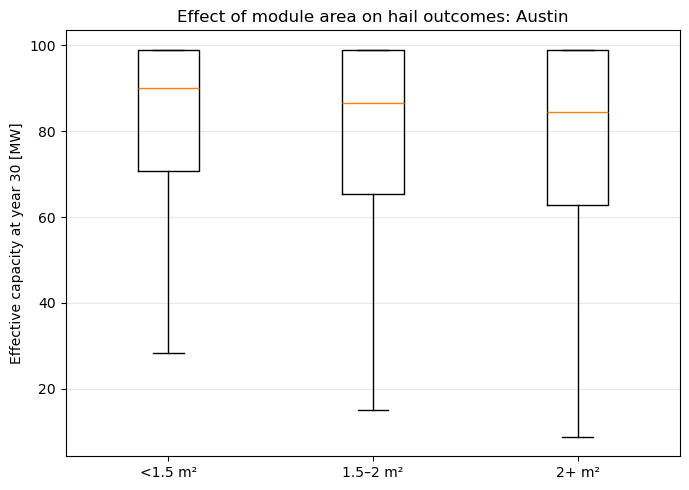

In [15]:
plt.figure(figsize=(7, 5))

plt.boxplot(
    list(area_eval.values()),
    labels=list(area_eval.keys()),
    showfliers=False
)

plt.ylabel(f"Effective capacity at year {evaluation_year} [MW]")
plt.title(f"Effect of module area on hail outcomes: Austin")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

In [16]:
# ## Summary by module-area case at evaluation year

evaluation_year = 30

area_summary = []

for label, mc in mc_by_area.items():

    x = mc.loc[
        mc["year"] == evaluation_year,
        "effective_capacity_MW_end"
    ]

    area_summary.append({
        "Module area": label,
        "Median capacity [MW]": np.median(x),
        "P10 capacity [MW]": np.percentile(x, 10),
        "P90 capacity [MW]": np.percentile(x, 90),
        "Median capacity [%]": 100 * np.median(x) / P0_MW,
        "P10 capacity [%]": 100 * np.percentile(x, 10) / P0_MW,
        "P90 capacity [%]": 100 * np.percentile(x, 90) / P0_MW,
    })

area_summary = pd.DataFrame(area_summary)

area_summary

,Module area,Median capacity [MW],P10 capacity [MW],P90 capacity [MW],Median capacity [%],P10 capacity [%],P90 capacity [%]
0,<1.5 m²,90.025742,50.253449,99.016432,90.025742,50.253449,99.016432
1,1.5–2 m²,86.585154,42.006361,99.016432,86.585154,42.006361,99.016432
2,2+ m²,84.541953,38.497160,99.016432,84.541953,38.497160,99.016432


In [20]:
mc.to_pickle("MC_results.pkl")

In [27]:
# ## Summary by module-area case at evaluation year

evaluation_year = 30

area_summary = []
i=0
csvtitle=['less1.5','1.5-2','2plus']
for label, mc in mc_by_area.items():
    
    x = mc.loc[
        mc["year"] == evaluation_year,
        "effective_capacity_MW_end"
    ]
    mytitle="Year30_"+csvtitle[i]+".csv"
    x.to_csv(mytitle)
    i+=1
    print(i)
    


1
2
3


In [25]:
csvtitle[1]

'1.5-2'

In [21]:
for label, mc in mc_by_area.items():
    print(label)

<1.5 m²
1.5–2 m²
2+ m²


In [ ]:
# ## Austin Monte Carlo capacity trajectories by module-area case

def summarize_mc_capacity(mc):
    return (
        mc.groupby("year")["effective_capacity_MW_end"]
        .agg(
            median="median",
            p10=lambda x: np.percentile(x, 10),
            p90=lambda x: np.percentile(x, 90),
        )
        .reset_index()
    )

area_summaries = {
    label: summarize_mc_capacity(mc)
    for label, mc in mc_by_area.items()
}

In [ ]:
plt.figure(figsize=(9, 5.5))

for label, summary in area_summaries.items():

    plt.plot(
        summary["year"],
        summary["median"],
        label=label
    )

    plt.fill_between(
        summary["year"],
        summary["p10"],
        summary["p90"],
        alpha=0.15
    )

plt.axvline(
    evaluation_year,
    linestyle="--",
    alpha=0.7,
    label=f"Evaluation year ({evaluation_year})"
)

plt.xlabel("Year")
plt.ylabel("Effective Capacity (MW)")
plt.title("Monte Carlo Effective Capacity by Module Area: Austin")
plt.legend(title="Module area")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# ## Fragility parameters used by module-area case

fragility_check = []

for label, module_area in module_cases.items():
    A, B, C, D, E = hs.get_fragility_params(
        module_area, fragility_curves
    )

    fragility_check.append({
        "Module area": label,
        "Selector area [m²]": module_area,
        "A": A,
        "B": B,
        "C": C,
        "D": D,
        "E": E,
    })

fragility_check = pd.DataFrame(fragility_check)
fragility_check

In [ ]:
# ## Hail-specific summary by module-area case

def summarize_hail_case(mc, label, evaluation_year):

    df = mc[mc["year"] <= evaluation_year]

    by_sim = df.groupby("sim").agg(
        any_county_hail=("county_hail_event", "any"),
        any_site_hit=("site_hit", "any"),
        n_site_hits=("site_hit", "sum"),
        hail_failures_MW=("hail_failures_MW", "sum"),
    )

    return {
        "Module area": label,
        "P(any county hail)": by_sim["any_county_hail"].mean(),
        "P(any site hit)": by_sim["any_site_hit"].mean(),
        "Mean site hits": by_sim["n_site_hits"].mean(),
        "Median hail loss [MW]": by_sim["hail_failures_MW"].median(),
        "P90 hail loss [MW]": by_sim["hail_failures_MW"].quantile(0.90),
    }


hail_area_summary = pd.DataFrame([
    summarize_hail_case(mc, label, evaluation_year)
    for label, mc in mc_by_area.items()
])

hail_area_summary

## Figures for Paper on Inputs

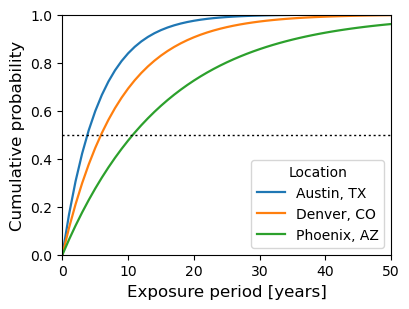

In [17]:
# --------------------------------------------------------------
# Model input figure: cumulative county-level hail probability
# --------------------------------------------------------------

plot_years = np.arange(0, 51)

location_labels = {
    "Austin": "Austin, TX",
    "Denver": "Denver, CO",
    "Phoenix": "Phoenix, AZ",
}

fig, ax = plt.subplots(figsize=(4.2, 3.2))

for loc in ["Austin", "Denver", "Phoenix"]:

    rp = hs.get_return_period(loc, hail_return)
    p_annual = 1 / rp

    cumulative_probability = (
        1 - (1 - p_annual) ** plot_years
    )

    ax.plot(
        plot_years,
        cumulative_probability,
        linewidth=1.6,
        label=location_labels[loc]
    )

ax.axhline(
    0.5,
    color="black",
    linestyle=(0, (1.5, 2)),
    linewidth=1.0
)

ax.set_xlabel("Exposure period [years]", fontsize=12)
ax.set_ylabel("Cumulative probability", fontsize=12)

ax.set_xlim(0, 50)
ax.set_ylim(0, 1.0)

ax.tick_params(axis="both", labelsize=10)

ax.legend(
    title="Location",
    fontsize=10,
    title_fontsize=10,
    frameon=True
)

plt.tight_layout()
plt.show()

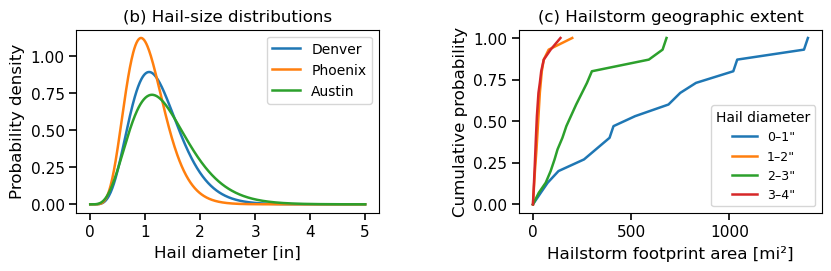

In [20]:
from scipy.stats import gamma

# --------------------------------------------------------------
# Figure 3: Probability of size exposure & hail severity
# --------------------------------------------------------------

fig, (ax1, ax2) = plt.subplots(
    1, 2,
    figsize=(8.2, 2.6),
    constrained_layout=True,
    gridspec_kw={"wspace": 0.18}
)

# ==============================================================
# (b) Location-specific hail-size distributions
# ==============================================================

hail_sizes = np.linspace(0, 5, 500)

for loc in ["Denver", "Phoenix", "Austin"]:

    shape, scale = hs.get_gamma_params(
        loc,
        hail_dist
    )

    pdf = gamma.pdf(
        hail_sizes,
        a=shape,
        scale=scale
    )

    ax1.plot(
        hail_sizes,
        pdf,
        linewidth=1.8,
        label=loc
    )

ax1.set_xlabel("Hail diameter [in]", fontsize=12)
ax1.set_ylabel("Probability density", fontsize=12)
ax1.set_title("(b) Hail-size distributions", fontsize=12)

ax1.tick_params(
    axis="both",
    labelsize=11,
    width=1.2,
    length=5
)

ax1.legend(
    fontsize=10,
    frameon=True
)

# ==============================================================
# (c) Hailstorm geographic extent
# ==============================================================

footprint_labels = {
    "0_1": '0–1"',
    "1_2": '1–2"',
    "2_3": '2–3"',
    "3_4": '3–4"',
}

for key, df in footprint_cdfs.items():

    ax2.plot(
        df["area_sqmi"],
        df["cumulative_probability"],
        linewidth=1.8,
        label=footprint_labels[key]
    )

ax2.set_xlabel("Hailstorm footprint area [mi²]", fontsize=12)
ax2.set_ylabel("Cumulative probability", fontsize=12)
ax2.set_title("(c) Hailstorm geographic extent", fontsize=12)

ax2.tick_params(
    axis="both",
    labelsize=11,
    width=1.2,
    length=5
)

ax2.legend(
    title="Hail diameter",
    fontsize=9,
    title_fontsize=10,
    frameon=True
)

plt.show()

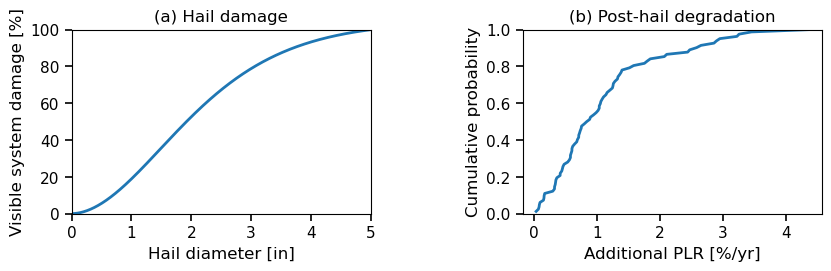

In [22]:
# --------------------------------------------------------------
# Figure 4: Hail damage and post-hail degradation
# --------------------------------------------------------------

fig, (ax1, ax2) = plt.subplots(
    1, 2,
    figsize=(8.2, 2.6),
    constrained_layout=True,
    gridspec_kw={"wspace": 0.22}
)

# ==============================================================
# (a) Hail size vs. visible system damage
# ==============================================================

hail_sizes = np.linspace(0, 5, 500)

# Overall/all-module-size fragility curve
row = fragility_curves.loc[
    fragility_curves["module_area_bin"] == "all_sizes"
].iloc[0]

damage_percent = hs.fragility_damage_percent(
    hail_sizes,
    row["A"],
    row["B"],
    row["C"],
    row["D"],
    row["E"]
)

ax1.plot(
    hail_sizes,
    damage_percent,
    linewidth=2
)

ax1.set_xlabel("Hail diameter [in]", fontsize=12)
ax1.set_ylabel("Visible system damage [%]", fontsize=12)
ax1.set_title("(a) Hail damage", fontsize=12)

ax1.set_xlim(0, 5)
ax1.set_ylim(0, 100)

ax1.tick_params(
    axis="both",
    labelsize=11,
    width=1.2,
    length=5
)


# ==============================================================
# (b) Post-hail PLR increase distribution
# ==============================================================

ax2.plot(
    plr_cdf["plr_percent_increase_peryear"],
    plr_cdf["cumulative_probability"],
    linewidth=2
)

ax2.set_xlabel("Additional PLR [%/yr]", fontsize=12)
ax2.set_ylabel("Cumulative probability", fontsize=12)
ax2.set_title("(b) Post-hail degradation", fontsize=12)

ax2.set_ylim(0, 1)

ax2.tick_params(
    axis="both",
    labelsize=11,
    width=1.2,
    length=5
)

plt.show()

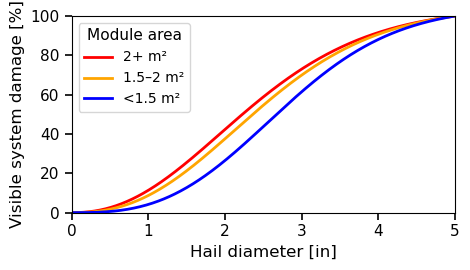

In [25]:
# --------------------------------------------------------------
# Figure 9: Visible system damage by module area
# --------------------------------------------------------------

hail_sizes = np.linspace(0, 5, 500)

fig, ax = plt.subplots(figsize=(4.8, 2.8))

area_styles = {
    "2+": {
        "label": "2+ m²",
        "color": "red",
    },
    "1.5-2": {
        "label": "1.5–2 m²",
        "color": "orange",
    },
    "<1.5": {
        "label": "<1.5 m²",
        "color": "blue",
    },
}

for area_bin, style in area_styles.items():

    row = fragility_curves.loc[
        fragility_curves["module_area_bin"] == area_bin
    ].iloc[0]

    damage_percent = hs.fragility_damage_percent(
        hail_sizes,
        row["A"],
        row["B"],
        row["C"],
        row["D"],
        row["E"]
    )

    ax.plot(
        hail_sizes,
        damage_percent,
        linewidth=2,
        label=style["label"],
        color=style["color"]
    )

ax.set_xlabel("Hail diameter [in]", fontsize=12)
ax.set_ylabel("Visible system damage [%]", fontsize=12)

ax.set_xlim(0, 5)
ax.set_ylim(0, 100)

ax.tick_params(
    axis="both",
    labelsize=11,
    width=1.2,
    length=5
)

ax.legend(
    title="Module area",
    fontsize=10,
    title_fontsize=11,
    frameon=True
)

plt.tight_layout()
plt.show()